## Baselines

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_price_data.csv", parse_dates=["timestamp"])
df = df.set_index("timestamp")

In [5]:
df["lag_1"] = df["price"].shift(1)
df["lag_24"] = df["price"].shift(24)
df["lag_168"] = df["price"].shift(168)

df.head()

,price,lag_1,lag_24,lag_168
timestamp,,,,
2023-01-08 00:00:00,10.93,NaN,NaN,NaN
2023-01-08 01:00:00,9.07,10.93,NaN,NaN
2023-01-08 02:00:00,9.10,9.07,NaN,NaN
2023-01-08 03:00:00,4.16,9.10,NaN,NaN
2023-01-08 04:00:00,5.58,4.16,NaN,NaN


In [6]:
df_baseline = df.dropna().copy()
df_baseline.head()


,price,lag_1,lag_24,lag_168
timestamp,,,,
2023-01-15 00:00:00,3.94,5.19,25.68,10.93
2023-01-15 01:00:00,1.71,3.94,34.62,9.07
2023-01-15 02:00:00,4.10,1.71,44.70,9.10
2023-01-15 03:00:00,2.65,4.10,41.23,4.16
2023-01-15 04:00:00,2.87,2.65,40.70,5.58


In [8]:
train = df_baseline.loc[: "2025-12-31"].copy()
test = df_baseline.loc["2026-01-01":].copy()

In [9]:
test["pred_lag_1"] = test["lag_1"]
test["pred_lag_24"] = test["lag_24"]
test["pred_lag_168"] = test["lag_168"]

In [11]:
from sklearn.metrics import mean_absolute_error

mae_lag_1 = mean_absolute_error(test["price"], test["pred_lag_1"])
mae_lag_24 = mean_absolute_error(test["price"], test["pred_lag_24"])
mae_lag_168 = mean_absolute_error(test["price"], test["pred_lag_168"])

print(f"Lag-1 Baseline MAE: {mae_lag_1:.3f}")
print(f"Lag-24 Baseline MAE: {mae_lag_24:.3f}")
print(f"Lag-168 Baseline MAE: {mae_lag_168:.3f}")

Lag-1 Baseline MAE: 7.604
Lag-24 Baseline MAE: 22.044
Lag-168 Baseline MAE: 25.697


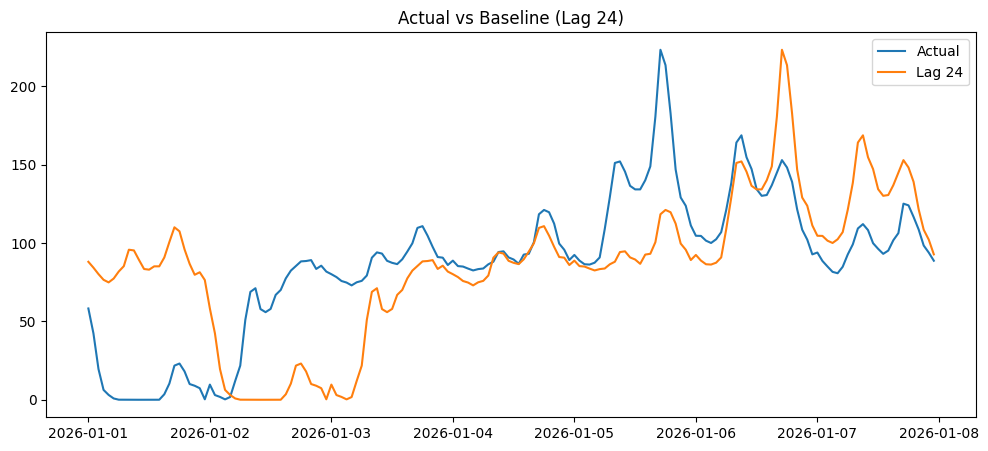

In [13]:
import matplotlib.pyplot as plt

sample = test["2026-01-01":"2026-01-07"]

plt.figure(figsize=(12,5))
plt.plot(sample.index, sample["price"], label="Actual")
plt.plot(sample.index, sample["pred_lag_24"], label="Lag 24")
plt.legend()
plt.title("Actual vs Baseline (Lag 24)")
plt.show()

lag_24 is the main realistic baseline because day-ahead prices are predicted 24 hours ahead.

lag_1 is included only as a reference, but it is not a realistic final baseline for day-ahead forecasting.

lag_168 captures the same hour from the previous week.

## Ridge only on time features

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_price_data.csv", parse_dates=["timestamp"])
df = df.set_index("timestamp")


In [3]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

import numpy as np

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["lag_24"] = df["price"].shift(24)
df["lag_48"] = df["price"].shift(48)
df["lag_168"] = df["price"].shift(168)

df["rolling_mean_24"] = df["price"].shift(1).rolling(24).mean()
df["rolling_std_24"] = df["price"].shift(1).rolling(24).std()

df = df.dropna()

In [4]:
train = df[: "2025-12-31"]
test = df["2026-01-01":]


In [5]:
features = [
    "hour", "dayofweek", "month",
    "hour_sin", "hour_cos",
    "lag_24", "lag_48", "lag_168",
    "rolling_mean_24", "rolling_std_24"
]

X_train = train[features]
y_train = train["price"]

X_test = test[features]
y_test = test["price"]

In [6]:
from sklearn.linear_model import Ridge

model = Ridge()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [7]:
from sklearn.metrics import mean_absolute_error

mae_model = mean_absolute_error(y_test, pred)

# baseline (lag_24)
mae_baseline = mean_absolute_error(y_test, test["lag_24"])

print("Model MAE:", mae_model)
print("Baseline MAE (lag_24):", mae_baseline)

Model MAE: 20.06179927367101
Baseline MAE (lag_24): 22.043645833333336


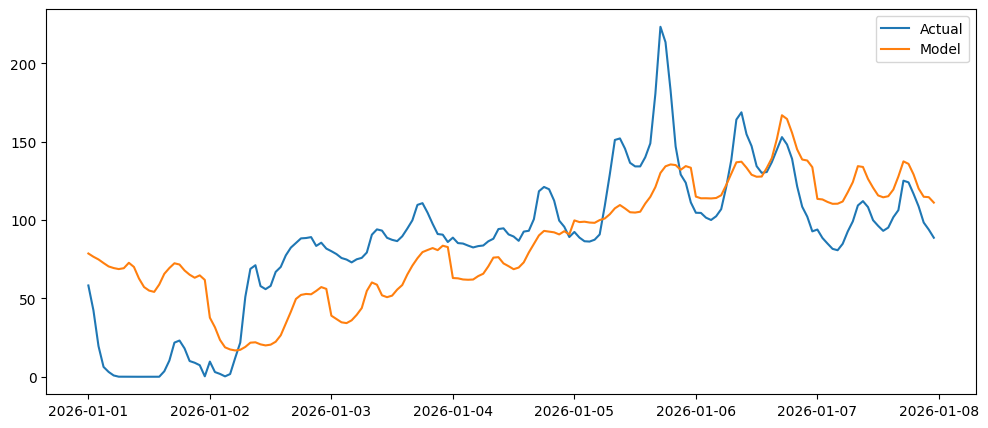

In [8]:
import matplotlib.pyplot as plt

sample = test["2026-01-01":"2026-01-07"]

plt.figure(figsize=(12,5))
plt.plot(sample.index, sample["price"], label="Actual")
plt.plot(sample.index, pred[:len(sample)], label="Model")
#plt.plot(sample.index, sample["lag_24"], label="Baseline (Lag 24)")

plt.legend()
plt.show()